In [235]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def sigmoid(z):
    # Prevents overflow in np.exp(-z) when z is extremely negative
    z_clipped = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z_clipped))


def get_data_mat(X):
 ## This takes the data matrix and returns an numpy array of the data with ones in the first column.
    X_arr = np.asarray(X)
    ones = np.ones((X_arr.shape[0], 1))
    return np.hstack((ones, X_arr)) 


def predict(beta, X):
 ## This function returns the vector of predictions. It is the sum of the products of the 
 ## coefficients times the predictor values. Use matrix notation to vectorize. obligatory cat keyboard mark ;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
    return np.dot(X, beta)


def get_loss(beta, X, y):
 ## Gets the loss function. Use matrix notation
   n = len(y)
   p = sigmoid(np.dot(X, beta))
   p = np.clip(p, 1e-15, 1 - 1e-15)  # Prevent log(0) errors
   #log loss
   loss = -(1 / n) * (np.dot(y.T, np.log(p)) + np.dot((1 - y).T, np.log(1 - p)))
   return loss    

In [236]:
def perform_gradient_descent(X, y, eta, num_iters):
    ## Arguments are data matrix X, targets y, learning rate eta, number of epochs num_iters
    X_b = get_data_mat(X)
    m, n = X_b.shape
    
    beta = np.random.normal(loc=0.0, scale=0.01, size=n)   
    loss_history = []
    
    #for a fixed number of iterations
    for i in range(num_iters):
       
        p = sigmoid(np.dot(X_b, beta))
        
        gradient = (1 / m) * np.dot(X_b.T, (p - y))
        
        beta -= eta * gradient
        

        loss = get_loss(beta, X_b, y)
        loss_history.append(loss)
        
    return beta, loss_history

In [237]:
def predict_proba(beta, X):
    X_b = get_data_mat(X)
    return sigmoid(np.dot(X_b, beta))

def predict(beta, X, threshold=0.5):
    return (predict_proba(beta, X) >= threshold).astype(int)

In [238]:
def plot_loss(loss_history):
    """Plots the training loss curve across epochs."""
    plt.figure(figsize=(8, 5))
    plt.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        color="tab:blue",
        linewidth=2,
    )
    plt.title("Loss vs. Epoch", fontsize=14)
    plt.xlabel("Epoch / Iteration", fontsize=12)
    plt.ylabel("Log-Loss", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

def get_accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

In [239]:
def start_model(data,eta, num_iters,scale=bool ):

    model = data
    if isinstance(model, pd.DataFrame):
        y = (model["species"] == "Adelie").astype(int).values
        X = model.drop(columns=["species"])
        X = pd.get_dummies(X, drop_first=True, dtype=int)
        
    else:
        X, y = model.data, model.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    beta_opt, loss_hist = perform_gradient_descent(
        X_train, y_train, eta, num_iters)
    y_preds = predict(beta_opt, X_test, threshold=0.5) 
    plot_loss(loss_hist)
    accuracy = get_accuracy(y_test,y_preds) 
    print(f"Accuracy (scaled:{scale}):{accuracy}, num_iters={num_iters}, lr={eta}")
    

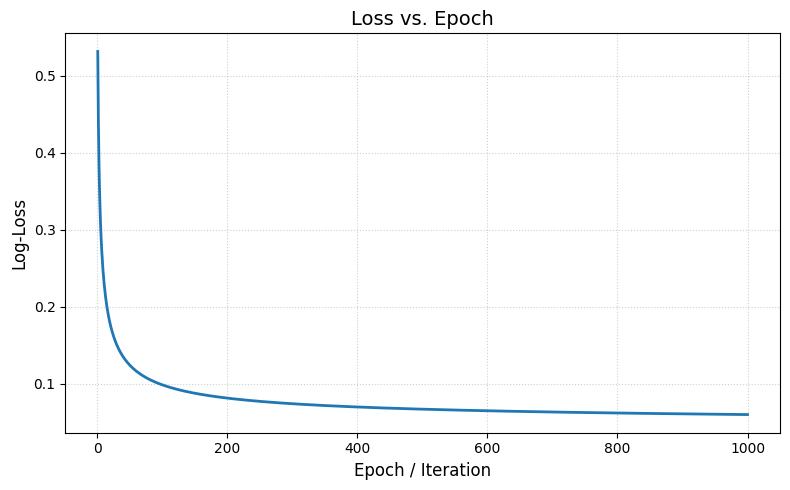

Accuracy (scaled:True):0.9766081871345029, num_iters=1000, lr=0.1


In [240]:
start_model(load_breast_cancer(), eta=0.1, num_iters=1000,scale=True)

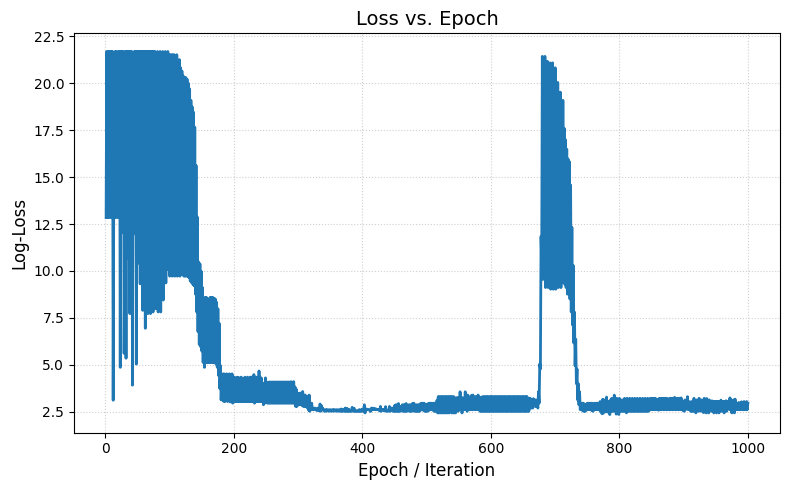

Accuracy (scaled:False):0.9005847953216374, num_iters=1000, lr=0.1


In [241]:
start_model(load_breast_cancer(), eta=0.1, num_iters=1000,scale=False)

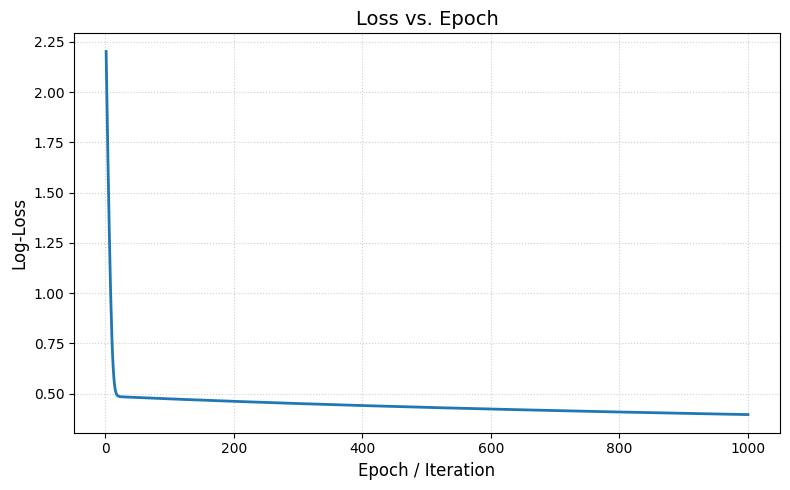

Accuracy (scaled:False):0.8830409356725146, num_iters=1000, lr=1e-06


In [242]:
start_model(load_breast_cancer(), eta=1e-6, num_iters=1000,scale=False)

In [243]:
import pandas as pd
penguin = pd.read_csv("../data/penguins.csv")
penguin

,...1,species,island,year,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,above_average_weight,sex
0,1,Adelie,Torgersen,2007,39.1,18.7,181,3750,0,male
1,2,Adelie,Torgersen,2007,39.5,17.4,186,3800,0,female
2,3,Adelie,Torgersen,2007,40.3,18.0,195,3250,0,female
3,5,Adelie,Torgersen,2007,36.7,19.3,193,3450,0,female
4,6,Adelie,Torgersen,2007,39.3,20.6,190,3650,0,male
...,...,...,...,...,...,...,...,...,...,...
328,340,Chinstrap,Dream,2009,55.8,19.8,207,4000,0,male
329,341,Chinstrap,Dream,2009,43.5,18.1,202,3400,0,female
330,342,Chinstrap,Dream,2009,49.6,18.2,193,3775,0,male
331,343,Chinstrap,Dream,2009,50.8,19.0,210,4100,0,male


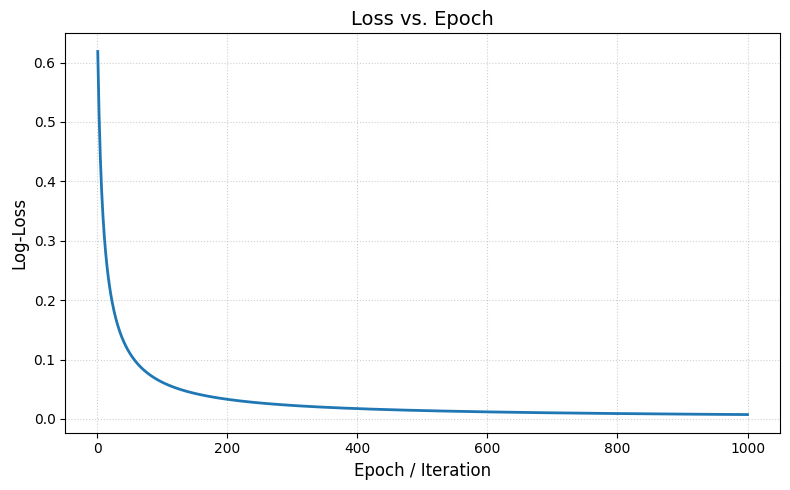

Accuracy (scaled:True):1.0, num_iters=1000, lr=0.1


In [244]:
start_model(penguin, eta=0.1, num_iters=1000,scale=True)

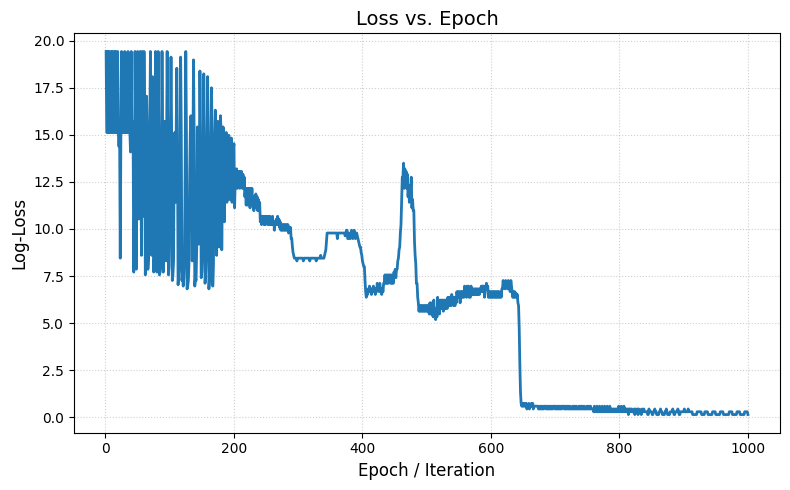

Accuracy (scaled:False):1.0, num_iters=1000, lr=0.1


In [245]:
start_model(penguin, eta=0.1, num_iters=1000,scale=False)

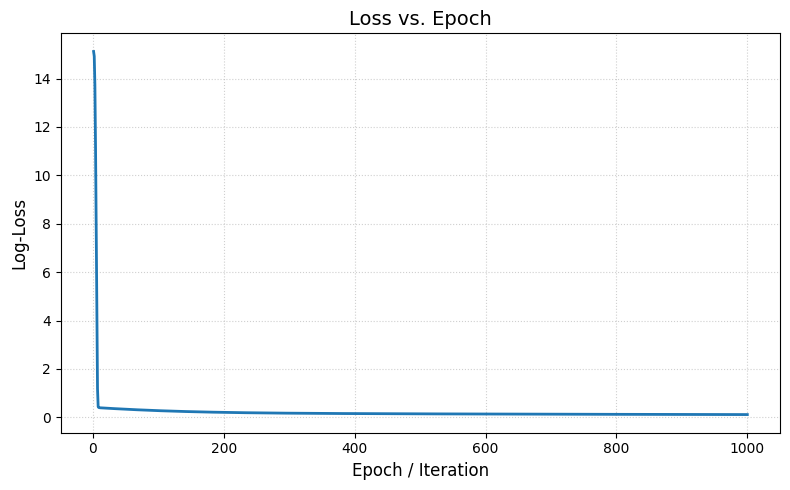

Accuracy (scaled:False):0.99, num_iters=1000, lr=1e-06


In [246]:
start_model(penguin, eta=1e-6, num_iters=1000,scale=False)

#### Begin Part 2 

In [247]:
def manual_metrics(y_true, y_pred):
  
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    print(f"MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: \n Accuracy {accuracy:0.4f} \n Precision: {precision:0.4f} \n Recall: {recall:0.4f}")

I use probabilities instead of logits because probabilities are between 0,1 and logits go from -inf,+INF

In [248]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve


def evaluate_roc_and_threshold(y_true, y_probs, min_tpr=0.70):
    """Computes AUC, plots ROC curve, finds threshold for TPR >= min_tpr,

    and evaluates performance at that threshold.
    """
    auc_score = roc_auc_score(y_true, y_probs)

  
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)

    thr_idx = np.argmax(tpr >= min_tpr)
    target_thr = thresholds[thr_idx]
    actual_tpr = tpr[thr_idx]
    actual_fpr = fpr[thr_idx]

    y_pred_thr = (y_probs >= target_thr).astype(int)

    cm = confusion_matrix(y_true, y_pred_thr)
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics at selected threshold
    confirmed_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"ROC Curve (AUC = {auc_score:.3f})",
    )
    plt.plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--",
        label="Random Guess",
    )
    plt.scatter(
        [actual_fpr],
        [actual_tpr],
        color="red",
        s=100,
        zorder=5,
        label=f"TPR >= {min_tpr} Threshold ({target_thr:.2f})",
    )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
    plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
    plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(f"SKLEARN ROC AND AUC GENERATED METRICS: \n auc: {auc_score:0.4f} \n threshold: {target_thr:0.4f} \n confusion_matrix: {cm} \n tpr: {confirmed_tpr:0.4f} \n specificity: {specificity:0.4f} \n precision: {precision:0.4f}")
    

In [249]:
def model_metrics(data,eta, num_iters,scale=bool ):

    model = data
    if isinstance(model, pd.DataFrame):
        y = (model["species"] == "Adelie").astype(int).values
        X = model.drop(columns=["species"])
        X = pd.get_dummies(X, drop_first=True, dtype=int)
        
    else:
        X, y = model.data, model.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    beta_opt, loss_hist = perform_gradient_descent(
        X_train, y_train, eta, num_iters)
    y_probs = predict_proba(beta_opt, X_test)
    y_preds = predict(beta_opt, X_test, threshold=0.5) 
    manual_metrics(y_test, y_preds)
    
    evaluate_roc_and_threshold(y_test,y_probs,min_tpr=0.7)
   
    

#### TESTING
I use load breast cancer first. Same as before, scaled and then unscaled. Unscaled will be same as before, using 0.1 LR and then 1e-6 LR 

MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 0.9766 
 Precision: 0.9813 
 Recall: 0.9813


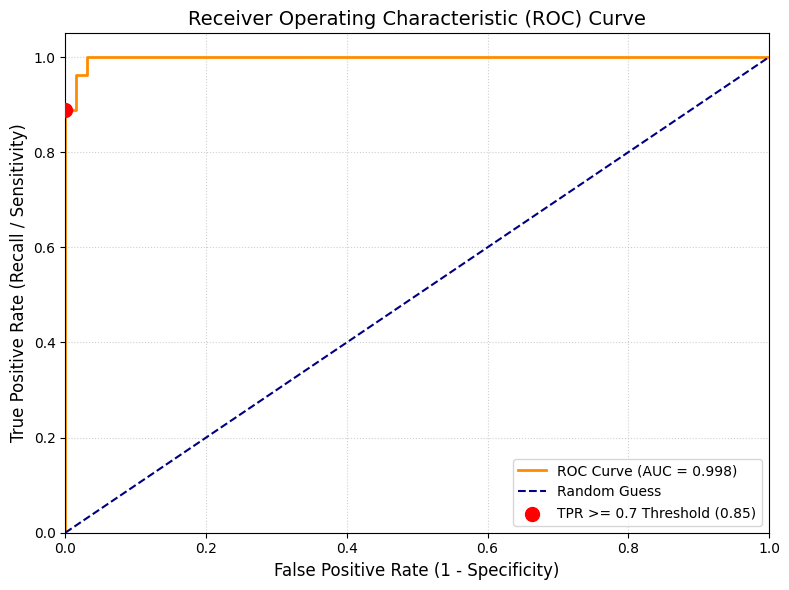

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 0.9977 
 threshold: 0.8512 
 confusion_matrix: [[64  0]
 [12 95]] 
 tpr: 0.8879 
 specificity: 1.0000 
 precision: 1.0000


In [250]:
model_metrics(load_breast_cancer(),eta=0.1, num_iters=1000,scale=True)

MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 0.8889 
 Precision: 0.9231 
 Recall: 0.8972


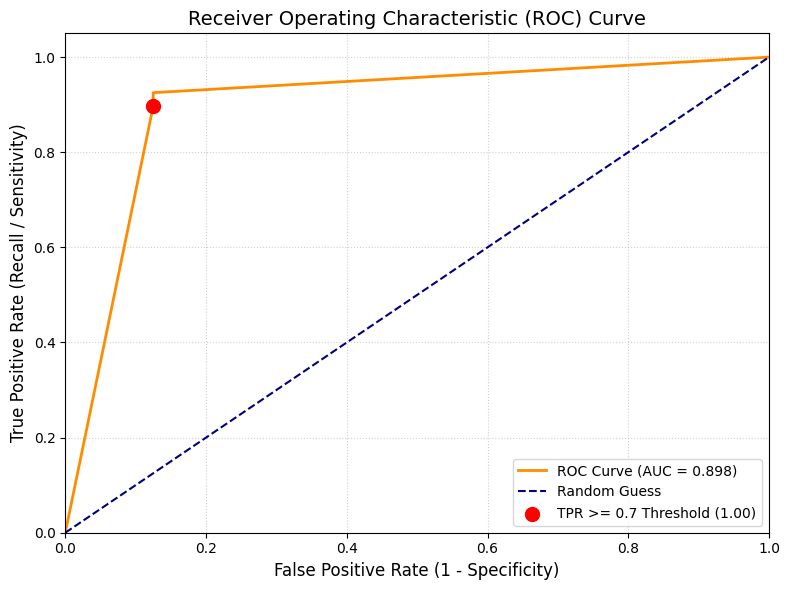

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 0.8984 
 threshold: 1.0000 
 confusion_matrix: [[56  8]
 [11 96]] 
 tpr: 0.8972 
 specificity: 0.8750 
 precision: 0.9231


In [251]:
model_metrics(load_breast_cancer(),eta=0.1, num_iters=1000,scale=False)

MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 0.9123 
 Precision: 0.8770 
 Recall: 1.0000


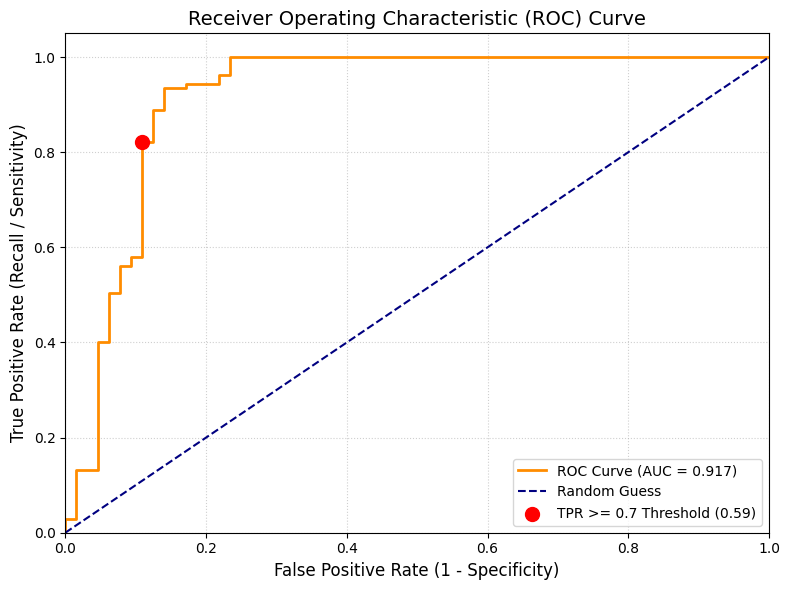

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 0.9173 
 threshold: 0.5930 
 confusion_matrix: [[57  7]
 [19 88]] 
 tpr: 0.8224 
 specificity: 0.8906 
 precision: 0.9263


In [252]:
model_metrics(load_breast_cancer(),eta=1e-6, num_iters=1000,scale=False)

Results  are clearly favoring scaled data with a reasonably large learning rate (0.1). Also there is literally 0 fale negatives on the scaled data model. Which in a pharmeceuitical setting, or any real diagnostic situation, is the most stringent classification. imagine if you had cancer but the test said you dont. you can see where im going here.

### now we move onto penguin

MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 1.0000 
 Precision: 1.0000 
 Recall: 1.0000


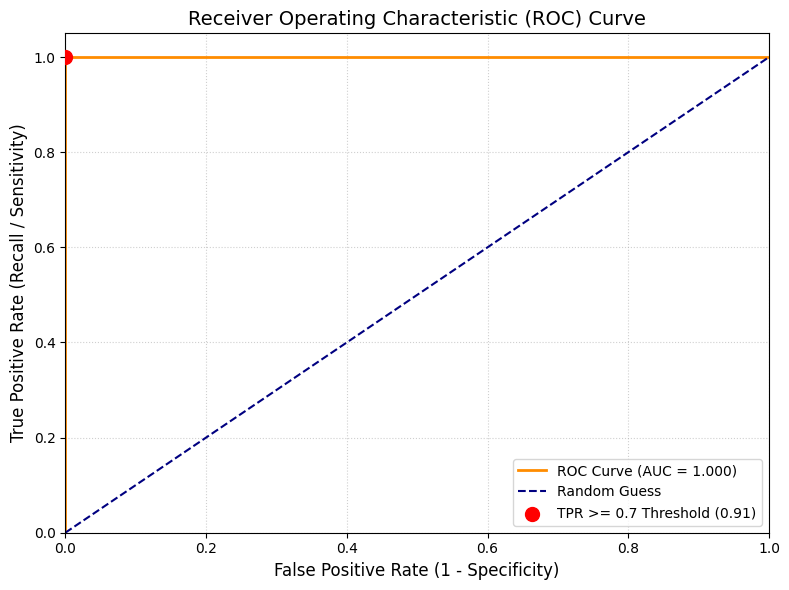

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 1.0000 
 threshold: 0.9056 
 confusion_matrix: [[56  0]
 [ 0 44]] 
 tpr: 1.0000 
 specificity: 1.0000 
 precision: 1.0000


In [253]:
model_metrics(penguin,eta=0.1, num_iters=1000,scale=True)

MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 1.0000 
 Precision: 1.0000 
 Recall: 1.0000


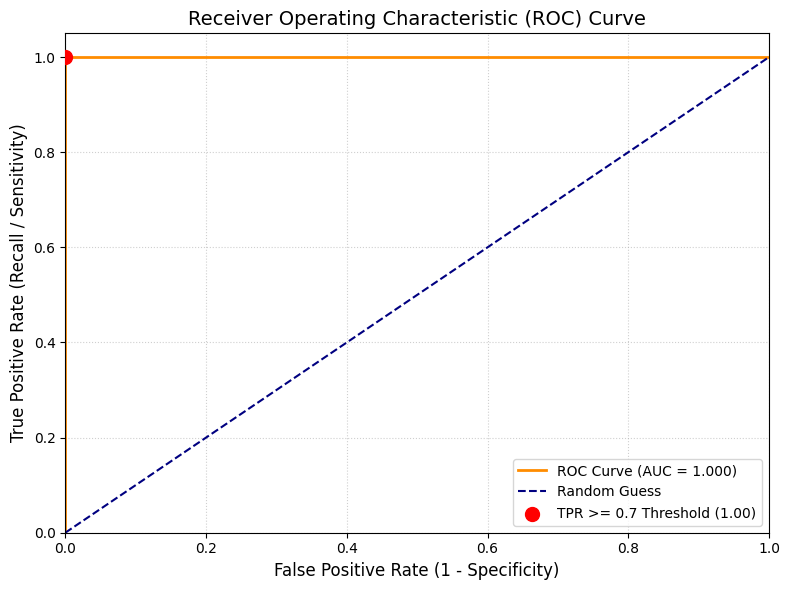

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 1.0000 
 threshold: 1.0000 
 confusion_matrix: [[56  0]
 [ 0 44]] 
 tpr: 1.0000 
 specificity: 1.0000 
 precision: 1.0000


In [254]:
model_metrics(penguin,eta=0.1, num_iters=1000,scale=False)

MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 0.9800 
 Precision: 0.9773 
 Recall: 0.9773


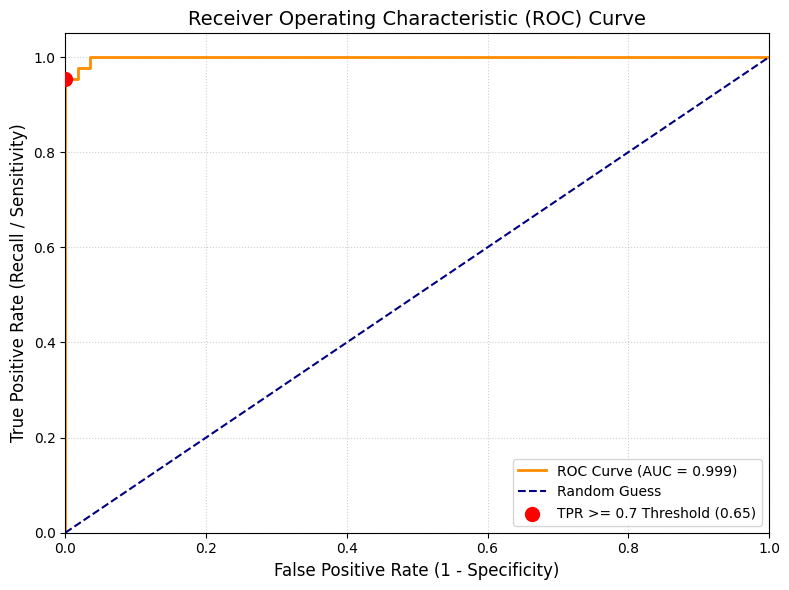

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 0.9988 
 threshold: 0.6544 
 confusion_matrix: [[56  0]
 [ 2 42]] 
 tpr: 0.9545 
 specificity: 1.0000 
 precision: 1.0000


In [255]:
model_metrics(penguin,eta=1e-6, num_iters=1000,scale=False)

#### Observations of penguin metrics

Pretty good overall. I did a thorough job preprocessing the data. 
I determine if the penguin is adelie or not which required changing the species column to one-hot.
I also changed the other 'X' string data to one hot using get_dummies which I think my models really agreed with.


I noticed with a large learning rate (0.1), that it did not matter on the penguin data set if I had scaled or not scaled the data. It is clear to me that my work one-hot encoding the data put the data on the same relative scale and thus made scaling kind of irrelivent. However, the unscaled penguin data on a 1e-6 learning rate caused 2 false positives. This is not completely awful but still I would not want to falsely diagnose two people with cancer. As I am writing this, I wonder what would happen if I try again with scaled data and a 1e-6 learning rate. 


MANUALLY CALCULATED ACCURACY, PRECISION, RECALL: 
 Accuracy 0.5800 
 Precision: 0.5200 
 Recall: 0.5909


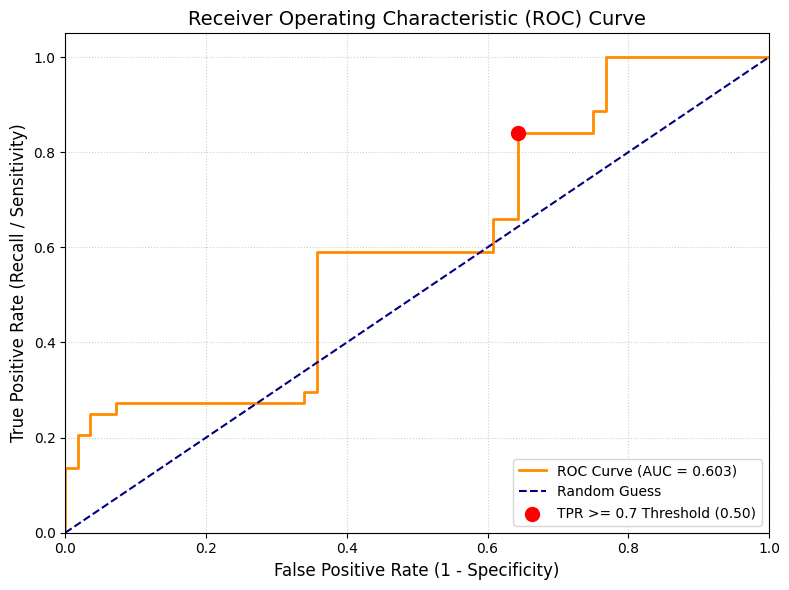

SKLEARN ROC AND AUC GENERATED METRICS: 
 auc: 0.6027 
 threshold: 0.4976 
 confusion_matrix: [[20 36]
 [ 7 37]] 
 tpr: 0.8409 
 specificity: 0.3571 
 precision: 0.5068


In [256]:
model_metrics(penguin,eta=1e-6, num_iters=1000,scale=True)

WOW looks like that completely ruined everything. So we can see how learning rate is significant. 

I think I have done enough to get an A on the assignment but I am sure that I made some mistake so I will look to read the professor's opinion when he grades. 

### Final thoughts on penguin model
 I put a lot more work into the penguin data set than I did with breast cancer. Encoding the data into one-hot style lead to favorable (perfect!) results as long as the learning rate is high enough (0.1). There were actually 0 false positives and negatives with 0.1 learning rate regardless of scaling.  